Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.callbacks import ModelCheckpoint

Importing the dataset

In [2]:
df = pd.read_csv('https://cainvas-static.s3.amazonaws.com/media/user_data/cainvas-admin/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


Data Analysis and Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [4]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 744 entries, 0 to 1568
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               744 non-null    int64  
 1   Glucose                   744 non-null    int64  
 2   BloodPressure             744 non-null    int64  
 3   SkinThickness             744 non-null    int64  
 4   Insulin                   744 non-null    int64  
 5   BMI                       744 non-null    float64
 6   DiabetesPedigreeFunction  744 non-null    float64
 7   Age                       744 non-null    int64  
 8   Outcome                   744 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 58.1 KB


In [6]:
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns:
    df[col].replace(0, np.NaN, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 744 entries, 0 to 1568
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               744 non-null    int64  
 1   Glucose                   739 non-null    float64
 2   BloodPressure             710 non-null    float64
 3   SkinThickness             529 non-null    float64
 4   Insulin                   385 non-null    float64
 5   BMI                       734 non-null    float64
 6   DiabetesPedigreeFunction  744 non-null    float64
 7   Age                       744 non-null    int64  
 8   Outcome                   744 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 58.1 KB


In [7]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381 entries, 1 to 1567
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               381 non-null    int64  
 1   Glucose                   381 non-null    float64
 2   BloodPressure             381 non-null    float64
 3   SkinThickness             381 non-null    float64
 4   Insulin                   381 non-null    float64
 5   BMI                       381 non-null    float64
 6   DiabetesPedigreeFunction  381 non-null    float64
 7   Age                       381 non-null    int64  
 8   Outcome                   381 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 29.8 KB


In [8]:
X = df.drop('Outcome', axis=1)
X = StandardScaler().fit_transform(X)
y = df['Outcome']

Test-Train Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0)

In [10]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((304, 8), (77, 8), (304,), (77,))

In [11]:
model = Sequential()
model.add(Dense(8, activation = 'relu', input_shape = X_train[0].shape))

model.add(Dense(8, activation='relu'))

model.add(Dense(4, activation='relu'))

model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 72        
                                                                 
 dense_1 (Dense)             (None, 8)                 72        
                                                                 
 dense_2 (Dense)             (None, 4)                 36        
                                                                 
 dense_3 (Dense)             (None, 1)                 5         
                                                                 
Total params: 185 (740.00 Byte)
Trainable params: 185 (740.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Model Training

In [12]:
opt = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer= opt ,loss='binary_crossentropy',metrics=['acc'])

In [13]:
checkpointer = ModelCheckpoint('diabetes.h5', monitor='val_acc', mode='max', verbose=2, save_best_only=True)
history=model.fit(X_train, y_train, batch_size=16, epochs=350, validation_data=(X_test, y_test), callbacks=[checkpointer])

Epoch 1/350
 1/19 [>.............................] - ETA: 45s - loss: 0.7304 - acc: 0.5000
Epoch 1: val_acc improved from -inf to 0.70130, saving model to diabetes.h5
19/19 [==============================] - 3s 20ms/step - loss: 0.6829 - acc: 0.6151 - val_loss: 0.6593 - val_acc: 0.7013
Epoch 2/350
 1/19 [>.............................] - ETA: 0s - loss: 0.8982 - acc: 0.5000
Epoch 2: val_acc did not improve from 0.70130
19/19 [==============================] - 0s 6ms/step - loss: 0.6807 - acc: 0.6151 - val_loss: 0.6569 - val_acc: 0.7013
Epoch 3/350
 1/19 [>.............................] - ETA: 0s - loss: 0.6835 - acc: 0.5000

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


15/19 [======================>.......] - ETA: 0s - loss: 0.6866 - acc: 0.6042
Epoch 3: val_acc did not improve from 0.70130
19/19 [==============================] - 0s 6ms/step - loss: 0.6784 - acc: 0.6250 - val_loss: 0.6546 - val_acc: 0.7013
Epoch 4/350
18/19 [===========================>..] - ETA: 0s - loss: 0.6763 - acc: 0.6389
Epoch 4: val_acc did not improve from 0.70130
19/19 [==============================] - 0s 6ms/step - loss: 0.6763 - acc: 0.6283 - val_loss: 0.6520 - val_acc: 0.7013
Epoch 5/350
 1/19 [>.............................] - ETA: 0s - loss: 0.7048 - acc: 0.6250
Epoch 5: val_acc did not improve from 0.70130
19/19 [==============================] - 0s 5ms/step - loss: 0.6741 - acc: 0.6316 - val_loss: 0.6495 - val_acc: 0.7013
Epoch 6/350
 1/19 [>.............................] - ETA: 0s - loss: 0.7063 - acc: 0.5000
Epoch 6: val_acc did not improve from 0.70130
19/19 [==============================] - 0s 5ms/step - loss: 0.6720 - acc: 0.6316 - val_loss: 0.6473 - val_acc:

In [14]:
present_model = keras.models.load_model('diabetes.h5')
present_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 72        
                                                                 
 dense_1 (Dense)             (None, 8)                 72        
                                                                 
 dense_2 (Dense)             (None, 4)                 36        
                                                                 
 dense_3 (Dense)             (None, 1)                 5         
                                                                 
Total params: 185 (740.00 Byte)
Trainable params: 185 (740.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [15]:
print("Accuracy of our model on test data : " , present_model.evaluate(X_test,y_test)[1]*100 , "%")


3/3 [==============================] - 0s 6ms/step - loss: 0.3700 - acc: 0.8442
Accuracy of our model on test data :  84.41558480262756 %


Training Plots

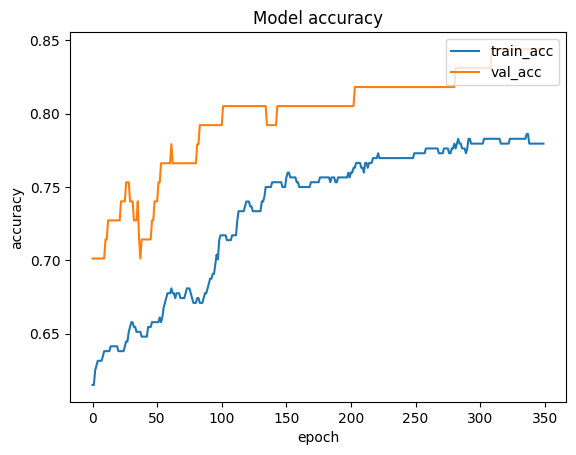

In [16]:
# plot the training artifacts
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train_acc','val_acc'], loc = 'upper right')
plt.show()

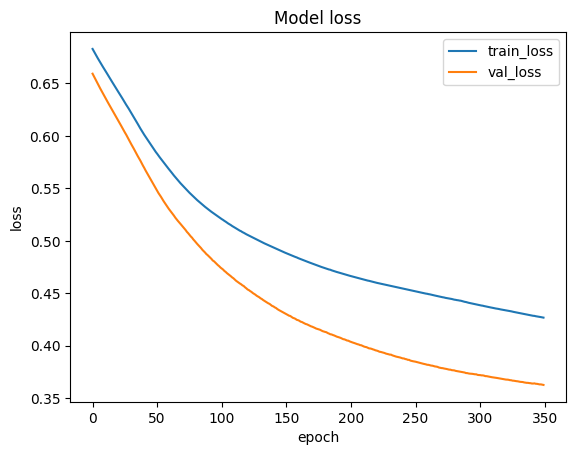

In [17]:
# plot the training artifacts

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss','val_loss'], loc = 'upper right')
plt.show()

Accessing the Performance of the Model

In [18]:
# predicting on test data.
pred_test = present_model.predict(X_test)
for i in range (len(pred_test)):
    if (pred_test[i] < 0.5):
        pred_test[i] = 0
    else:
        pred_test[i] = 1
pred_test = pred_test.astype(int)

3/3 [==============================] - 0s 5ms/step


In [19]:
def view_result(array):
    array = np.array(array)
    for i in range(len(array)):
        if array[i] == 0:
            print("Not Diabetic")
        else:
            print("Diabetic")

In [20]:
view_result(pred_test[:10])

Not Diabetic
Not Diabetic
Not Diabetic
Diabetic
Not Diabetic
Diabetic
Diabetic
Not Diabetic
Not Diabetic
Diabetic


In [21]:
view_result(y_test[:10])

Not Diabetic
Not Diabetic
Not Diabetic
Diabetic
Not Diabetic
Diabetic
Diabetic
Not Diabetic
Not Diabetic
Diabetic


Save the model

In [24]:
present_model.save("diabetes.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
